# Thème Image - TP3 - Introduction au filtrage

## Notebook
* A tout moment, vous pouvez savoir dans quel répertoire vous vous trouvez en utilisant la commande `pwd`et lister les fichiers qui s'y trouvent avec la commande `ls`.

* Accèdez au dossier de travail, pour cela utilisez les commandes `pwd` (print working directory), `cd` (change directory) et `ls`(list contents) pour naviguer sur le disque.

* Changez de repertoire jusqu'a voir tous les fichiers necessaires au TP.

* Familiarisez vous avec les fonctions mises à votre disposition dans le fichier `utils.py`; elles vous seront utiles pour la suite.

* Pour commencer, executez la cellule suivante afin d'avoir accès à votre espace disque.

* Vérifiez que vous êtes au bon endroit, et que tous les fichiers nécessaires au TP sont bien présents. Utilisez la commande `ls` pour cela.

In [1]:
pwd

'c:\\Users\\magda\\Desktop\\TP3'

In [2]:
ls

 Le volume dans le lecteur C n'a pas de nom.
 Le num�ro de s�rie du volume est 4052-8B07

 R�pertoire de c:\Users\magda\Desktop\TP3

04/02/2025  08:51    <DIR>          .
04/02/2025  08:51    <DIR>          ..
04/02/2025  08:51    <DIR>          __pycache__
04/02/2025  08:35            86�247 dx.png
04/02/2025  08:35           110�786 dx_desert.png
04/02/2025  08:35           105�402 dx_fruits.png
04/02/2025  08:35           310�873 dx_sweets.png
04/02/2025  08:35           502�689 dx_tissu.png
04/02/2025  08:35           273�530 dx_tomates.png
04/02/2025  08:35            86�738 dy.png
04/02/2025  08:35           108�202 dy_desert.png
04/02/2025  08:35            98�298 dy_fruits.png
04/02/2025  08:35           317�538 dy_sweets.png
04/02/2025  08:35           464�290 dy_tissu.png
04/02/2025  08:35           284�217 dy_tomates.png
04/02/2025  08:35            66�614 papillon.bmp
04/02/2025  08:35            66�614 papillon_noise.bmp
04/02/2025  08:35           361�078 sweets.bmp
04/02

* Importez les modules dont vous aurez besoin en exécutant la cellule suivante (`Shift+Enter`).

In [3]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

plt.ion()

import sys
sys.path.append('..')
from utils import *

test_utils()

Test utils ok


# Objectifs du TP
* Aborder concrètement la notion de filtrage, d'abord en 1D puis en 2D
* Etudier deux filtres de lissage : filtre moyenne et filtre gaussien
* Application : lissage d'une image bruitée
* Comparer l'effet des deux filtres

# Exercice 1
## Filtrage 1D

On s'intéresse dans un premier temps au filtrage de signaux 1D.

Dans le cadre du filtrage numérique, on travaille sur des vecteurs de nombres.
L'idée du filtrage est de  promener une "fenêtre" sur chacun des éléments du vecteur, et obtenir une nouvelle valeur à partir des éléments de cette fenêtre.


In [4]:
# Creer un vecteur d'indices de taille N (N pourra etre modifie par la suite)
N = 10
s = np.arange(N)
print(f's= {s}')

s= [0 1 2 3 4 5 6 7 8 9]


## Extraction d'un patch et parcours du signal

* Etant donné un indice $u$ et un entier $m$, comment construire le sous-tableau de $s$ contenant les $2m+1$ éléments suivants :
$s(u-m), ..., s(u), ..., s(u+m)$ ?

* Pour quelles valeurs de $u$ est-il possible de construire ce sous-tableau ?

On appelle *patch* un tel sous-tableau.

In [5]:
# Ecrire une fonction permettant d'extraire la fenetre de valeurs [u-m, ..., u, ..., u+m]
def get_patch(vec, u, m):
    if u - m < 0 or u + m >= len(vec):
        return None
    
    patch = []
    for i in range(u-m, u+m+1):
        patch.append(vec[i])
    return np.array(patch)

In [6]:
# Tester la fonction: que se passe-t-il lorsque u=0 ou u=N-1?
# Autre cas problematiques?
test_patch = get_patch(s, 5, 2)
print(f'test_win= {test_patch}')

test_win= [3 4 5 6 7]


In [7]:
# Ecrire une fonction qui verifie les bornes de la fenetre
def check_and_get_patch(vec, u, m):
    # Check
    # A COMPLETER
    if u - m < 0 or u + m >= len(vec):
        return False, None
    
    # Compute
    patch = []
    # A COMPLETER
    for i in range(u-m, u+m + 1):
        patch.append(vec[i])
    return True, np.array(patch)


In [8]:
# Tester check_and_get_window
test_check_and_get_window = check_and_get_patch(s, 5, 2)
print(f'test= {test_check_and_get_window}')

test= (True, array([3, 4, 5, 6, 7]))


In [9]:
# Ecrire une fonction qui extrait toutes les fenetres admissibles a partir du vecteur vec
def print_all_patches(vec, m):
    # A COMPLETER
    for u in range(len(vec)):
        ok, patch = check_and_get_patch(vec,u,m)
        if ok:
            print(f'u= {u} --> {patch}')

* Pour un vecteur de taille 10, et un rayon $m = 2$ vous devriez obtenir les patchs suivants :
- u = 2 --> [0, 1, 2, 3, 4]
- u = 3 --> [1, 2, 3, 4, 5]
- u = 4 --> [2, 3, 4, 5, 6]
- u = 5 --> [3, 4, 5, 6, 7]
- u = 6 --> [4, 5, 6, 7, 8]
- u = 7 --> [5, 6, 7, 8, 9]

In [10]:
# Tester
print_all_patches(s, 2)

u= 2 --> [0 1 2 3 4]
u= 3 --> [1 2 3 4 5]
u= 4 --> [2 3 4 5 6]
u= 5 --> [3 4 5 6 7]
u= 6 --> [4 5 6 7 8]
u= 7 --> [5 6 7 8 9]


In [11]:
# Refaire le test avec un tableau de valeurs 'physiques'
s2 = np.sin(s)  # np.sin transforme le tableau en [sin(0), sin(1), sin(2), ...]
print(f's2 = {s2}')
print_all_patches(s2, 3)

s2 = [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155   0.6569866   0.98935825  0.41211849]
u= 3 --> [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155 ]
u= 4 --> [ 0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427 -0.2794155
  0.6569866 ]
u= 5 --> [ 0.90929743  0.14112001 -0.7568025  -0.95892427 -0.2794155   0.6569866
  0.98935825]
u= 6 --> [ 0.14112001 -0.7568025  -0.95892427 -0.2794155   0.6569866   0.98935825
  0.41211849]


# Exercice 2
## Filtre moyenne

L'application du filtre moyenne consiste à remplacer la valeur d'un élément par la moyenne arithmétique des valeurs sur un patch centré autour de cet élément.

On note $W = \frac{1}{2M+1}\begin{pmatrix}1&\cdots&1\end{pmatrix}$ la fenêtre de longueur 2M+1, dont tous les éléments sont identiques et dont la somme vaut 1.

1. A quelle opération correspond l'instruction `np.sum(p*W)`, où `p` est un patch ?


2. En vous inspirant de l'exercice précédent, écrire une fonction qui, à partir d'un tableau $s$, renvoie le tableau $s_{mean}$ défini de la façon suivante :
  * si on peut définir un patch de taille $2m+1$ autour de l'indice $u$, $s_{mean}[u]$ est la moyenne des éléments de la fenêtre,
  * sinon $s_{mean}[0] = 0$.

**Indication** : Vous pourrez utiliser la fonction `check_and_get_patch` pour extraire de manière sécurisée les patches, et l'instruction précédente pour calculer la moyenne.

_Exemple :_
L'application du filtre moyen de rayon $m=1$ sur le vecteur $s = [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]$ doit produire $s_{mean}= [0, 0, 0, 0, 1, 2, 3, 3, 3, 0]$.

3. Que pensez-vous de ce résultat ?

In [12]:
# Ecrire une fonction permettant d'appliquer un filtre moyen sur un vecteur
def mean_filter(vec, m):
    mean_vec = []  # Nouveau vecteur de valeurs
    # A COMPLETER
    for i in XXX:
        ok, patch = XXX
        if ok:
            mean_val = XXX
        else:
            mean_val = XXX
        ...
    return np.array(mean_vec)


In [13]:
# Definir un vecteur de valeurs
s = [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]
print(f's= {s}')

# Lisser
s_mean = mean_filter(s, 1)

# Comparer
print(f's_mean= {s_mean}')
fig,ax = plt.subplots()
ax.plot(s,label='s')
ax.plot(s_mean,label='s_mean')
ax.set_title('Vecteur test et moyenne')
ax.legend()


s= [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]


NameError: name 'XXX' is not defined

* Essayer avec un vecteur plus long, contenant des valeurs 'physiques' et du bruit.

In [ ]:
# Generer le signal pur
M = 100
s = np.sin(2 * np.pi * np.arange(M) / M)

# Generer un bruit blanc (distribution aleatoire uniforme)
noise_magnitude = 0.3
noise = noise_magnitude * np.random.randint(-100, +100, M) / 100

# Appliquer le bruit au signal
s = s + noise

# Filtrer
s_mean = mean_filter(s, 5)

# Comparer
fig,ax = plt.subplots()
ax.plot(s,label='Original')
ax.plot(s_mean,label='Mean')
ax.legend()
ax.set_title('Vecteur bruité et moyenne')


# Exercice 3
## Moyenne pondérée

La moyenne arithmétique accorde un poids égal à chacun des pixels sur une fenêtre donnée (tous les coefficients de $W$ sont égaux). On considère d'autres types de moyennes, dites pondérées,
où un poids différent peut être accordé à chaque pixel.

Dans un cadre totalement différent, pensez à la note du baccalauréat qui est obtenue en affectant des coeficients différents selon les matières, en faisant la somme de toutes ces notes, puis en divisant par la somme des coefficients
pour ramener la note sur 20.

Ici, on fait de même : étant donné une fenêtre $W$ de taille $2m+1$ et un vecteur $s$, on veut construire un vecteur $s2$ tel que:
*  pour chaque indice $u$, $s2[u]$ contient la moyenne pondérée par les poids $W$ sur le patch
de taille $2m+1$ autour de l'élément d'indice $u$ si on peut définir cette fenêtre
* $0$ sinon.

1. Etant donné un vecteur $W$ de taille $2m+1$ qu'on suppose normalisé (dont la somme des coefficients vaut 1), et un tableau $s$ contenant un signal, comment calculer $s2$ la moyenne pondérée de $s$ par les poids $W$ ?

**Indications** : la fonction numpy.sum() calcule la somme des éléments d'un tableau. L'opérateur * permet de multiplier terme à terme deux tableaux dans numpy. Voir l'exemple dans la cellule ci-dessous.

In [14]:
# Exemple d'utilisation des opérateurs de numpy
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(a*b)
print(np.sum(a * b))

[ 4 10 18]
32


In [17]:
# Ecrire une fonction qui calcule une moyenne ponderee en appliquant un filtre
def extract_patch(s, i, m):
    if i - m < 0 or i + m >= len(s):
        return False, None
    return True, s[i - m:i + m + 1]

def apply_filter(s, W):
    s2 = []
    # A COMPLETER
    m = int((len(W) - 1) / 2)  # Que se passe-t-il si le filtre a une taille paire ?
    # Si W paire, (len(W) - 1) / 2 risque de donner un flottant
    for i in range(len(s)):
        ok, patch = extract_patch(s, i, m)
        if ok:
            mean_val = np.sum(patch * W)
        else:
            mean_val = 0
        s2.append(mean_val)
    return np.array(s2)

s= [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]
W= [0.25 0.5  0.25]
s_wmean= [0.   0.   0.   0.   0.75 2.25 3.   3.   3.   0.  ]


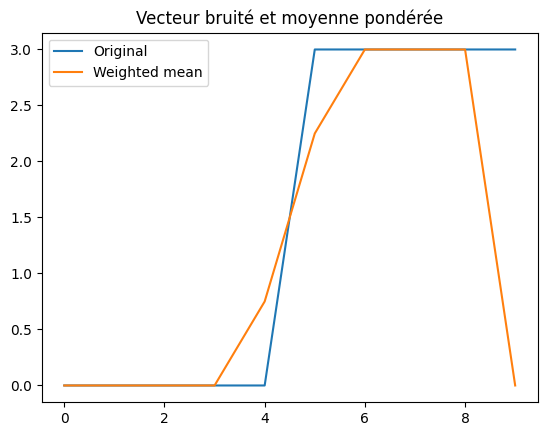

In [18]:
# Definir un vecteur de valeurs
s = [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]
print(f's= {s}')

# Definir un filtre de moyenne ponderee
W = np.array([0.5, 1.0, 0.5]) / 2.0
print(f'W= {W}')

# Tester
s_wmean = apply_filter(s, W)

# Comparer
fig,ax = plt.subplots()
ax.plot(s,label='Original')
ax.plot(s_wmean,label='Weighted mean')
ax.legend()
ax.set_title('Vecteur bruité et moyenne pondérée')
print(f's_wmean= {s_wmean}')


* Pour vérifier votre implémentation, testez avec les poids $1/3*[1, 1, 1]$: vous devez retrouver le même résultat qu'à l'exercice précédent.

W= [0.33333333 0.33333333 0.33333333]
s= [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]
s_mean= [0. 0. 0. 0. 1. 2. 3. 3. 3. 0.]


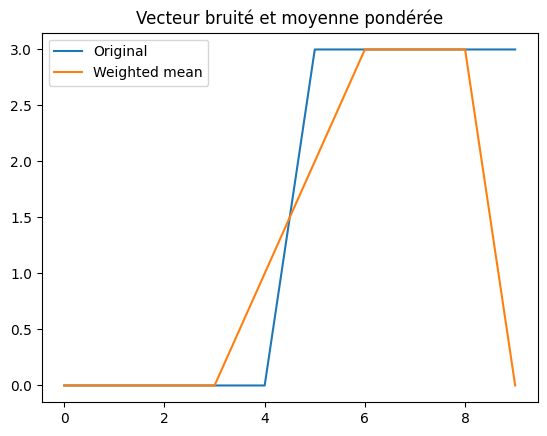

In [19]:
# En utilisant le filtre moyen de l'exercice precedent, on doit retrouver le meme resultat
# A COMPLETER
W = np.array([1, 1, 1]) / 3
print(f'W= {W}')

s = [0, 0, 0, 0, 0, 3, 3, 3, 3, 3]
print(f's= {s}')

s2 = apply_filter(s, W)
print(f's_mean= {s2}')

fig,ax = plt.subplots()
ax.plot(s,label='Original')
ax.plot(s2,label='Weighted mean')
ax.legend()
ax.set_title('Vecteur bruité et moyenne pondérée')
plt.show()


* Que se passe-t-il si on ne normalise pas le filtre ?

Text(0.5, 1.0, 'Filtre NON normalisé')

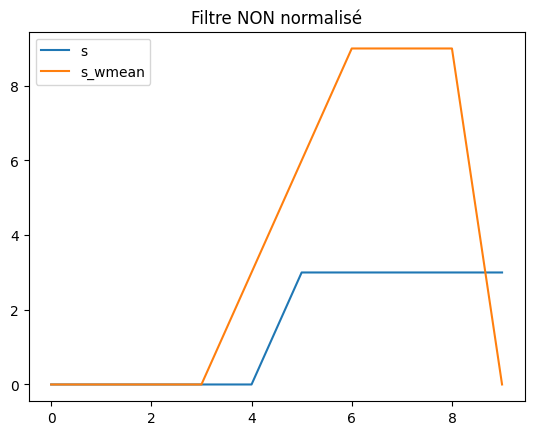

In [20]:
W = np.array([1.0, 1.0, 1.0])  # Pas de normalisation: / 3.0
s_wmean = apply_filter(s, W)

# Afficher
fig,ax = plt.subplots()
ax.plot(s,label='s')
ax.plot(s_wmean,label='s_wmean')
ax.legend()
ax.set_title("Filtre NON normalisé")


# Exercice 4
## Filtre gaussien

La fonction gaussienne $f(x) = e^{-\frac{x^2}{2\sigma^2}}$ a une forme de chapeau qui est intéressante pour construire une moyenne pondérée avec une
valeur plus importante sur l'élément central de la fenêtre et une décroissance rapide et régulière sur les autres éléments.

De plus la largeur du chapeau est contrôlée par le paramètre $\sigma$ (sigma), ce qui permet d'obtenir facilement une famille de filtres de taille plus ou moins grande.

In [21]:
# Fonction gaussienne
def f(x, sig):
    # A COMPLETER
    return XXX

In [ ]:
# Courbes gaussiennes pour quelques valeurs de sigma
x = np.arange(-5.0, +5.0, 0.1)

fig, ax = plt.subplots()
for sigma in [1.5, 1.0, 0.5]:
  y = [f(x, sigma) for x in x]
  ax.plot(x, y, label=f'Sigma={sigma}')

_ = ax.legend()

L'idée du filtre gaussien consiste à prendre les valeurs de $f(x)$ pour $x$ parcourant des ensembles de la forme $\lbrace -L, \ldots, 0, \ldots, L\rbrace$ où $L$ est choisi tel que $f(L+1)$ soit négligeable devant $f(0) = 1$.

Par exemple pour $\sigma = 0.5$ (voir courbe ci-dessus), on a
$f(0) = 1, f(1) \approx 0.135, f(2) \approx 0.0003$, donc $f(2)$ est négligeable devant $f(0)$.

Si on prend $L=1$ les poids correspondant à $\sigma = 0.5$ sont
$[0.135, 1, 0.135]$ avant normalisation.



In [ ]:
simga = 0.5
print(f'f(0)= {f(0, sigma)}')
print(f'f(1)= {f(1, sigma)}')
print(f'f(2)= {f(2, sigma)}')

# Et evidemment
print('\nLa distribution gaussienne est paire, donc')
print(f'f(-1)= f(1)= {f(-1, sigma)}')
print(f'f(-2)= f(2)= {f(-2, sigma)}')

De manière générale, on se fixe un seuil $\varepsilon$ et pour une valeur de $\sigma$ donnée, et on choisit la taille $L$ du filtre de telle manière que $f(L) > \varepsilon$ et $f(L + 1) < \varepsilon$.

* Montrez que  $f(L) > \varepsilon \Longleftrightarrow L < \sigma\sqrt{-2\log(\varepsilon)}$.

* Modifiez la cellule suivante pour définir une fonction qui calcule le tableau $[f(-L), ..., f(0), ..., f(L)]$ où $L$ est le plus grand entier vérifiant $f(L) > \varepsilon$ en fonction de paramètres $\sigma$ et $\epsilon$. Cette fonction doit ensuite renvoyer le tableau normalisé (dont la somme des éléments est égale à 1).

In [ ]:
# Ecrire une fonction qui genere un filtre gaussien de parametre sigma de taille max
def get_gauss_filter(sigma, epsilon):
    # Trouver le plus grand entier L tel que f(L) > epsilon
    # f(L) > eps <==> abs(L) < sig sqrt(-2 ln(eps)) i.e., L < sig sqrt(-2 ln(eps)), puisque L>0
    # A COMPLETER
    L = XXX
    
    # # Debug
    # print(f'Check f(L)   >  {epsilon}: {f(L, sigma)}')
    # print(f'Check f(L+1) <= {epsilon}: {f(L+1, sigma)}')

    # Calculer les poids
    w = []
    for i in range(-L, +L + 1):
        # A COMPLETER
        w.append(XXX)
        
    # Normaliser les poids pour obtenir le filtre
    w_sum = sum(w)
    # A COMPLETER
    fil = XXX
    return fil

* On fixe $\varepsilon = 10^{-3}$.

* Vous pouvez tester votre fonction pour $\sigma = 0.5$ et $\epsilon=0.001$ `get_gauss_filter` doit renvoyer $[0.106507 0.786986 0.106507]$. Remarquez qu'on a bien $\sum_i g_i = 1$.

_**IMPORTANT** : Vous devez avoir terminé cet exercice et obtenu le résultat demandé car vous aurez besoin de la fonction `get_gauss_filter` pour le reste de cette séance et (au moins) la séance suivante._

In [ ]:
# On se donne un epsilon
eps = 0.001

# Test
get_gauss_filter(0.5, 0.001)

* Remplissez le tableau suivant qui indique la taille du tableau en fonction de quelques valeurs de $\sigma$ :
  * $\sigma = 0.5 \Rightarrow size = ?$
  * $\sigma = 1.0 \Rightarrow size = ?$
  * $\sigma = 1.5 \Rightarrow size = ?$
  * $\sigma = 2.0 \Rightarrow size = ?$

Ici, $size$ est la taille du filtre, c'est-à-dire la taille du tableau, c'est-à-dire $2*L + 1$.

In [ ]:
# Calculer les longueurs des filtres gaussiens pour les valeurs de sigma suivantes
sigma = [0.1,1,1.5,2]
sizes = []
# A COMPLETER
print(sizes)

# Exercice 5
## Lissage d'un signal bruité

Nous allons extraire un signal bruité à partir de l'image papillon_noise.bmp. La cellule ci-dessous extrait la ligne 128 de l'image et l'affiche sous forme de courbe.

Text(0.5, 1.0, "Une ligne extraite de l'image")

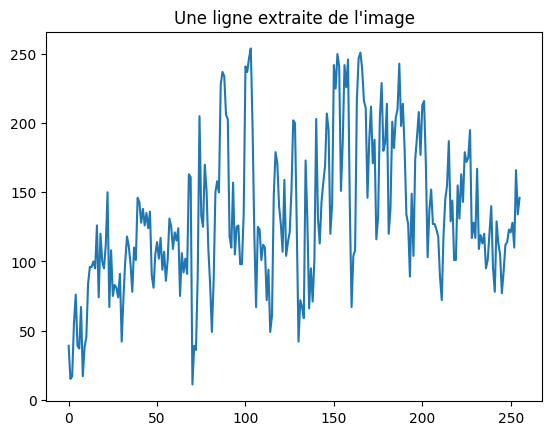

In [22]:
# Charger et afficher l'image
img = plt.imread('papillon_noise.bmp')

# Extraire la ligne 128
row = img[128, :]

# Afficher le vecteur
fig, ax = plt.subplots()
ax.plot(row,label='Noisy')
ax.set_title("Une ligne extraite de l'image")



* Testez l'effet du filtre moyenne sur le vecteur $row$ en augmentant progressivement la taille de la fenêtre : 3, 5, 11, 21.

NameError: name 'XXX' is not defined

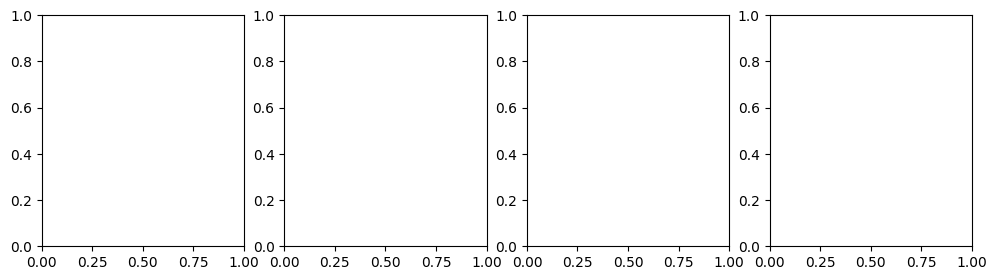

In [53]:
fig,ax = plt.subplots(1,4,figsize=(12,3))
# Lisser avec filtres moyens de taille 3, 5, 11, 21
for i, size in enumerate([3, 5, 11, 21]):
    # A COMPLETER
    mean_fil = XXX
    mean_row = apply_filter(row, mean_fil)

    # Afficher chaque paire
    ax[i].plot(row,label="Original")
    ax[i].plot(mean_row,label=f'Size:{size}')
ax.legend()


* Testez l'effet du filtre Gaussien sur le vecteur $row$ en augmentant progressivement la valeur de $\sigma$ : 0.5, 1, 3, 5.

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(12,3))
# Lisser avec filtres gaussiens de parametre sigma 0.5, 1, 1.5, 2
for i, sigma in enumerate([0.5,1.,1.5,2.]):
    # A COMPLETER
    fil = XXX
    filtered_row = apply_filter(row, mean_fil)

    # Afficher chaque paire
    ax[i].plot(row,label="Original")
    ax[i].plot(filtered_row,label=f'Sigma:{sigma}')
ax.legend()


In [ ]:
fig, ax = plt.subplots()
ax.plot(row,label='Original')

# Lisser avec des filtres gaussiens, avec sigma= 0.5, 1, 3, 5
gauss_filtering = [row]
for sigma in [0.5, 1, 3, 5]:
    # A COMPLETER
    gauss_fil = XXX
    gauss_row = XXX
    
    # Afficher chaque paire
    ax.plot(gauss_row,label=f'Sigma = {sigma}')
ax.legend()

# Exercice 6
## Filtrage 2D

On se place maintenant dans le cadre du filtrage appliqué aux images. Le signal ici est constitué des valeurs des pixels dans un tableau à deux dimensions et les fenêtres que l'on va déplacer sur l'image (i.e. les filtres) sont des carrés centrés sur le pixel considéré.

## Construction du patch et parcours de l'image

Soit $im$ un tableau de taille $M \times N$ contenant une image.

* Etant donné un pixel désigné par un couple d'indices $(u,v)$ et un entier $m$, comment construire le patch de $im$ contenant les $(2m+1)^2$ éléments autour du pixel ?

* Pour quelles valeurs de $(u,v)$ est-il possible de construire ce patch ?

In [24]:
# Ecrire une fonction qui extrait une fenetre centree sur (u, v) taille (2*m + 1)x(2*m + 1)


def check_and_get_patch_2D(img, u, v, m):
    # Check
    M, N = img.shape
    # A COMPLETER
    if u-m < 0 or u + m >= M:
        return False, None
    
    # Check
    # A COMPLETER
    if v-m < 0 or v + m >= N:
        return False, None
    
    # Compute
    patch = np.empty((2*m+1, 2*m+1))
    for i in range(2*m+1):
        for j in range(2*m+1):
            # A COMPLETER
            patch[i, j] = img[u-m+i, v-m+j]
    return True, patch

* Testez votre fonction à l'aide de la cellule ci-dessous.

In [26]:
# Construire un tableau 2D d'indices
im = np.zeros([10, 10])
for i in range(im.shape[0]):
    for j in range(im.shape[1]):
        im[i, j] = i*10 + j

print(im)

# Test 1
ok, win = check_and_get_patch_2D(im, 1, 1, 2)
print(f'Should be False: {ok}')

# Test 2
m = 2
ok, win = check_and_get_patch_2D(im, 3, 3, m)
print(f'Should be True: {ok}')
print(f'Window (size= {2*m+1}x{2*m+1}) should be centered on element "33"=\n{win}')

# Autres tests
# A completer...

# Construire un tableau 2D d'indices
im = np.zeros([10, 10])
for i in range(im.shape[0]):
    for j in range(im.shape[1]):
        im[i, j] = i * 10 + j

print("Image générée :\n", im)

# Test 1: Patch trop grand pour être extrait
ok, win = check_and_get_patch_2D(im, 1, 1, 2)
print(f'Should be False: {ok}')

# Test 2: Patch valide centré sur (3,3)
m = 2
ok, win = check_and_get_patch_2D(im, 3, 3, m)
print(f'Should be True: {ok}')
print(f'Window (size={2*m+1}x{2*m+1}) should be centered on element "33":\n{win}')

# Autres tests

# Test 4: Patch dépassant en haut de l'image
ok, win = check_and_get_patch_2D(im, 0, 5, 2)
print(f'Should be False: {ok}')



[[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18. 19.]
 [20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
 [30. 31. 32. 33. 34. 35. 36. 37. 38. 39.]
 [40. 41. 42. 43. 44. 45. 46. 47. 48. 49.]
 [50. 51. 52. 53. 54. 55. 56. 57. 58. 59.]
 [60. 61. 62. 63. 64. 65. 66. 67. 68. 69.]
 [70. 71. 72. 73. 74. 75. 76. 77. 78. 79.]
 [80. 81. 82. 83. 84. 85. 86. 87. 88. 89.]
 [90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]]
Should be False: False
Should be True: True
Window (size= 5x5) should be centered on element "33"=
[[11. 12. 13. 14. 15.]
 [21. 22. 23. 24. 25.]
 [31. 32. 33. 34. 35.]
 [41. 42. 43. 44. 45.]
 [51. 52. 53. 54. 55.]]
Image générée :
 [[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18. 19.]
 [20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
 [30. 31. 32. 33. 34. 35. 36. 37. 38. 39.]
 [40. 41. 42. 43. 44. 45. 46. 47. 48. 49.]
 [50. 51. 52. 53. 54. 55. 56. 57. 58. 59.]
 [60. 61. 62. 63. 64. 65. 66. 67. 68. 69.]
 [70. 71. 72. 73. 74. 75. 76. 77. 78

* Initialisez l'image $im$ en exécutant la cellule ci-dessous.

In [27]:
# Test 3
im = np.array([[1, 0, 0, 0],
               [0, 2, 0, 0],
               [0, 0, 3, 0],
               [0, 0, 0, 4]])


* Trouvez toutes les fenêtres de taille 3x3 de ce tableau.

Vous devez obtenir le resultat suivant :

    -----------------
    [[1. 0. 0.]
     [0. 2. 0.]
     [0. 0. 3.]]
    -----------------
    [[0. 0. 0.]
     [2. 0. 0.]
     [0. 3. 0.]]
    -----------------
    [[0. 2. 0.]
     [0. 0. 3.]
     [0. 0. 0.]]
    -----------------
    [[2. 0. 0.]
     [0. 3. 0.]
     [0. 0. 4.]]

In [28]:
m = 1
for u in range(im.shape[0]):
    for v in range(im.shape[1]):
        # A COMPLETER
        ok, win = check_and_get_patch_2D(im, u, v, m)
        if ok:
            print('-----------------')
            print(win)

-----------------
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]
-----------------
[[0. 0. 0.]
 [2. 0. 0.]
 [0. 3. 0.]]
-----------------
[[0. 2. 0.]
 [0. 0. 3.]
 [0. 0. 0.]]
-----------------
[[2. 0. 0.]
 [0. 3. 0.]
 [0. 0. 4.]]


# Exercice 7
## Filtre moyenne

De même qu'en 1D, l'application de ce filtre consiste à calculer la nouvelle valeur d'un pixel comme étant la  moyenne des valeurs sur une patch centré autour de lui.

* En vous inspirant de l'exercice précédent, écrivez une fonction qui à partir d'une image $im$ renvoie l'image $im2$ définie de la façon suivante :
  * pour chaque couple d'indices $(u,v)$, $im2[u,v]$ contient la moyenne du patch de taille $(2m+1)^2$ autour de $im(u,v)$ si le patch est défini, et sinon $0$.

* Vous pouvez tester avec une image simple contenant un carré noir sur fond blanc.

* Vous pouvez faire varier la taille de la fenêtre et observer le résultat.


In [29]:
# Ecrire une fonction qui applique un filtre moyen a une image

def check_and_get_patch_2D(img, u, v, m):
    if u - m < 0 or u + m >= img.shape[0]:
        return False, None
    if v - m < 0 or v + m >= img.shape[1]:
        return False, None
    patch = img[u - m:u + m + 1, v - m:v + m + 1]
    
    return True, patch

def mean_filter_2D(img, m):
    # Creer une image vide de la meme taille que l'image en entree
    mean_img = np.empty(img.shape)

    # Appliquer le filtre
    for u in range(img.shape[0]):
        for v in range(img.shape[1]):
            # A COMPLETER
            ok, patch = check_and_get_patch_2D(img, u, v, m)
            if ok:
                mean_img[u, v] = np.mean(patch)
            else:
                mean_img[u, v] = 0

    return mean_img

Text(0.5, 1.0, 'Filtre moyen')

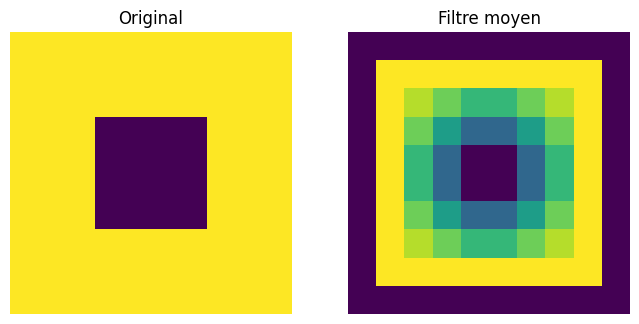

In [30]:
fig,ax = plt.subplots(1,2,figsize=(8,4))
# Creer une image d'un carre noir sur fond blanc
square = np.ones((10, 10)) * 255
square[3:7, 3:7] = 0

# Afficher
ax[0].imshow(square)
ax[0].set_axis_off()
ax[0].set_title('Original')


# Test 1
mean_square = mean_filter_2D(square, 1)
ax[1].imshow(mean_square)
ax[1].set_axis_off()
ax[1].set_title('Filtre moyen')


* Faites de même avec l'image papillon.bmp, avec des filtres 3x3 et 11x11.

* Que pensez-vous du résultat pour $m=5$ ?

Text(0.5, 1.0, 'Filtre moyen 5x5')

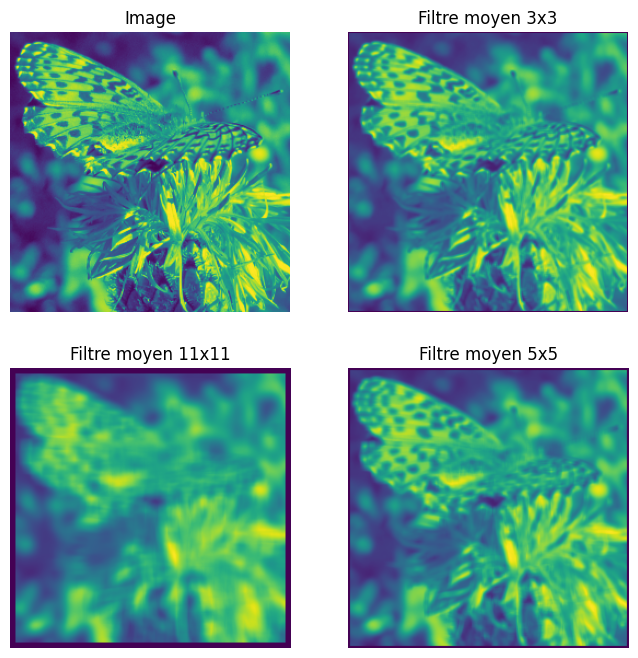

In [31]:
fig,ax = plt.subplots(2,2,figsize=(8,8))
# Charger l'image
test_img = plt.imread('./papillon.bmp')
ax[0,0].imshow(test_img)
ax[0,0].set_axis_off()
ax[0,0].set_title('Image')

# Test 2
# A COMPLETER
mean_test_img = mean_filter_2D(test_img, m=1)
ax[0,1].imshow(mean_test_img)
ax[0,1].set_axis_off()
ax[0,1].set_title('Filtre moyen 3x3')

# Test 3
# A COMPLETER
mean_test_img = mean_filter_2D(test_img, m=5)
ax[1,0].imshow(mean_test_img)
ax[1,0].set_axis_off()
ax[1,0].set_title('Filtre moyen 11x11')

mean_test_img = mean_filter_2D(test_img, m=2)
ax[1,1].imshow(mean_test_img)
ax[1,1].set_axis_off()
ax[1,1].set_title('Filtre moyen 5x5')




# Exercice 8
## Moyenne pondérée 2D

On étend en 2D la moyenne pondérée définie dans l'exercice 3.

* Etant donné une fenêtre $W$ de taille $(2m+1)^2$ qu'on suppose normalisée (i.e. la somme des coefficients vaut 1), et une image $im$ contenant un signal, comment calculer la moyenne pondérée par les poids $W$ ?

_**Indications** : l'opérateur numpy $*$ réalise le produit terme à terme de deux tableaux, et la fonction $np.sum$ renvoie la somme des éléments d'un tableau._

* Modifiez la fonction dans la cellule ci-dessous pour qu'elle réalise l'opération de moyenne pondérée par les poids $W$ sur les éléments de l'image $im$ et renvoie le résultat.

In [ ]:
# Ecrire une fonction qui applique un filtre en 2D a une image
def apply_filter_2D(im, W):
    fil_img = np.empty(im.shape)
    
    # Que se passe-t-il si le filtre a une taille paire ?
    if np.mod(W.shape[0],2) == 0 or np.mod(W.shape[1],2) == 0:
        raise ValueError("Le filtre doit avoir une longueur impaire.")
    else:
        m = int((W.shape[0] - 1) / 2)
    
    # Quels autres controles faudrait il mettre en place?

    # Calculer l'image filtree
    for u in range(im.shape[0]):
        for v in range(im.shape[1]):
            # A COMPLETER
            ok, patch = XXX
            if ok:
                mean_val = XXX
            else:
                mean_val = XXX
            fil_img[u, v] = mean_val
    return fil_img


* Testez avec les poids `W = (1/9)*np.ones(3,3)`, vous devez retrouver le même résultat qu'à l'exercice précédent.

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(8,4))

# Creer un filtre moyen 3x3 (m=1)
W = np.ones((3, 3)) / 9
print(f'W=\n{W}')

# Test 1: carre noir sur fond blanc
square = np.ones((10, 10)) * 255
square[3:7, 3:7] = 0
ax[0].imshow(square)
ax[0].set_axis_off()
ax[0].set_title('Square')
#
# A COMPLETER
mean_square = XXX
ax[1].imshow(mean_square)
ax[1].set_axis_off()
ax[1].set_title('Carré + fitre')


* Faites de même avec l'image papillon.bmp.

In [ ]:
# Test 2

fig,ax = plt.subplots(1,2,figsize=(8,4))

# Creer un filtre moyen 3x3 (m=1)
W = np.ones((3, 3)) / 9
print(f'W=\n{W}')

# Test 1: carre noir sur fond blanc
im = plt.imread('./papillon.bmp')
ax[0].imshow(im)
ax[0].set_axis_off()
ax[0].set_title('Original')
#
# A COMPLETER
mean_img = XXX
ax[1].imshow(mean_img)
ax[1].set_axis_off()
ax[1].set_title('Original + fitre')

# Exercice 9
## Filtre gaussien

On peut étendre à deux dimensions la fonction gaussienne vue auparavant :
$f_{2D}(x,y) = e^{-\frac{x^2+y^2}{2\sigma^2}}$. Elle possède les mêmes bonnes propriétés pour obtenir des poids : valeur plus importante sur l'élément central de la fenêtre et décroissance régulière; de plus elle ne possède pas de direction privilégiée.

Par ailleurs, on peut observer que $f_{2D}(x,y) = e^{-\frac{x^2}{2\sigma^2}}e^{-\frac{y^2}{2\sigma^2}} = f(x)f(y)$, ce qui implique qu'on peut construire le filtre gaussien $G2D$ correspondant à $f_{2D}$ à partir du filtre gaussien 1D $G$ construit plus haut :
$\tt \forall (i,j), G2D(i,j) = G(i)*G(j)$

* Modifiez la cellule ci-dessous pour qu'elle renvoie le tableau $G2D$ décrit ci-dessus. Il y a (au moins) deux façons de faire : soit en réutilisant les termes du filtre 1D, soit en repartant du calcul de $L$ puis en échantillonnant la fonction $f_{2D}$.

* Pour $\sigma=0.5$ et $\epsilon=0.001$ e tableau doit contenir les valeurs suivantes :

|           |           |           |
|-----------|-----------|-----------|
| 0.0113437 | 0.0838195 | 0.0113437 |
| 0.0838195 | 0.619347  | 0.0838195 |
| 0.0113437 | 0.0838195 | 0.0113437 |


* Remarquez qu'on a bien $\sum_{i, j} \texttt{G2D}_{ij} = 1$.

In [33]:
def f(x, sigma):
    return np.exp(- (x ** 2) / (2 * sigma ** 2))
# Ecrire une fonction gaussienne 2D
def f_2D(x, y, sig):
    return f(x, sig)*f(y, sig)

# Ecrire une fonction qui calcule une filtre gaussien en 2D
def get_gauss_filter_2D(sigma, epsilon):
    # A COMPLETER
    # Trouver le plus grand entier L tel que f(L) > epsilon
    L = 0
    while f(L, sigma) > epsilon:
        L += 1
    L -= 1

    # # Debug
    print(f'Check f(L)   >  {epsilon}: {f(L, sigma)}')
    print(f'Check f(L+1) <= {epsilon}: {f(L+1, sigma)}')

    # Calculer les poids
    w = np.empty((2*L+1, 2*L+1))
    for i in range(-L, L + 1):
        for j in range(-L, L + 1):
            w[i + L, j + L] = f_2D(i, j, sigma)

    # Normaliser les poids pour obtenir le filtre
    w /= np.sum(w)
    return w
    
# Test
G2D = get_gauss_filter_2D(sigma=0.5, epsilon=0.001)
print(f'G2D=\n{G2D}')
print(f'somme= {np.sum(G2D)}')

Check f(L)   >  0.001: 0.1353352832366127
Check f(L+1) <= 0.001: 0.00033546262790251185
G2D=
[[0.01134374 0.08381951 0.01134374]
 [0.08381951 0.61934703 0.08381951]
 [0.01134374 0.08381951 0.01134374]]
somme= 1.0


* Vous pouvez maintenant utiliser la fonction de l'exercice précédent pour appliquer le filtre gaussien sur l'image papillon.bmp.

* Vous pouvez faire varier $\sigma$.

* Que pensez-vous du résultat pour $\sigma = 2.5$ en comparaison avec le résultat avec un filtre moyenne de grande taille ?

* Comparer a l'image produite par un filtre moyen de grande taille (m=5) plus haut.

Check f(L)   >  0.001: 0.001533810679324463
Check f(L+1) <= 0.001: 0.00033546262790251185


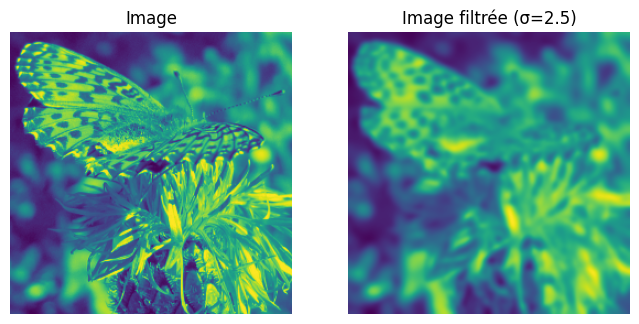

G2D (19, 19)=
[[5.99234950e-08 2.33473520e-07 7.75159384e-07 2.19309412e-06
  5.28732997e-06 1.08624663e-05 1.90166210e-05 2.83694649e-05
  3.60646581e-05 3.90683777e-05 3.60646581e-05 2.83694649e-05
  1.90166210e-05 1.08624663e-05 5.28732997e-06 2.19309412e-06
  7.75159384e-07 2.33473520e-07 5.99234950e-08]
 [2.33473520e-07 9.09657964e-07 3.02017080e-06 8.54471862e-06
  2.06004596e-05 4.23222684e-05 7.40924314e-05 1.10532919e-04
  1.40514879e-04 1.52217952e-04 1.40514879e-04 1.10532919e-04
  7.40924314e-05 4.23222684e-05 2.06004596e-05 8.54471862e-06
  3.02017080e-06 9.09657964e-07 2.33473520e-07]
 [7.75159384e-07 3.02017080e-06 1.00273202e-05 2.83694649e-05
  6.83959346e-05 1.40514879e-04 2.45995535e-04 3.66982215e-04
  4.66525829e-04 5.05381397e-04 4.66525829e-04 3.66982215e-04
  2.45995535e-04 1.40514879e-04 6.83959346e-05 2.83694649e-05
  1.00273202e-05 3.02017080e-06 7.75159384e-07]
 [2.19309412e-06 8.54471862e-06 2.83694649e-05 8.02633727e-05
  1.93506942e-04 3.97547088e-04 6.95

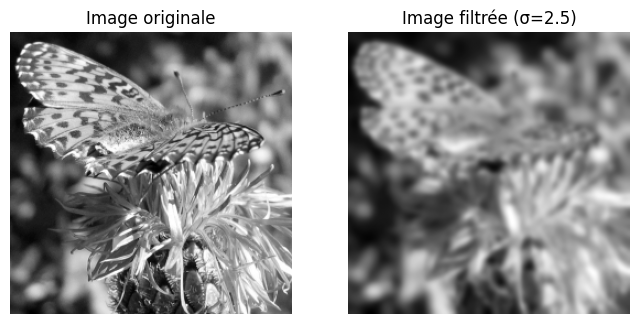

G2D (19, 19)=
[[5.99234950e-08 2.33473520e-07 7.75159384e-07 2.19309412e-06
  5.28732997e-06 1.08624663e-05 1.90166210e-05 2.83694649e-05
  3.60646581e-05 3.90683777e-05 3.60646581e-05 2.83694649e-05
  1.90166210e-05 1.08624663e-05 5.28732997e-06 2.19309412e-06
  7.75159384e-07 2.33473520e-07 5.99234950e-08]
 [2.33473520e-07 9.09657964e-07 3.02017080e-06 8.54471862e-06
  2.06004596e-05 4.23222684e-05 7.40924314e-05 1.10532919e-04
  1.40514879e-04 1.52217952e-04 1.40514879e-04 1.10532919e-04
  7.40924314e-05 4.23222684e-05 2.06004596e-05 8.54471862e-06
  3.02017080e-06 9.09657964e-07 2.33473520e-07]
 [7.75159384e-07 3.02017080e-06 1.00273202e-05 2.83694649e-05
  6.83959346e-05 1.40514879e-04 2.45995535e-04 3.66982215e-04
  4.66525829e-04 5.05381397e-04 4.66525829e-04 3.66982215e-04
  2.45995535e-04 1.40514879e-04 6.83959346e-05 2.83694649e-05
  1.00273202e-05 3.02017080e-06 7.75159384e-07]
 [2.19309412e-06 8.54471862e-06 2.83694649e-05 8.02633727e-05
  1.93506942e-04 3.97547088e-04 6.95

In [38]:
from scipy.signal import convolve2d

sigma = 2.5
G2D = get_gauss_filter_2D(sigma=sigma, epsilon=0.001)

im_filtered = convolve2d(im, G2D, mode='same', boundary='symm')

# Test 2
fig, ax = plt.subplots(1,2,figsize=(8,4))

# Test 2
im = plt.imread('./papillon.bmp')
ax[0].imshow(im)
ax[0].set_axis_off()
ax[0].set_title('Image')
# A COMPLETER
ax[1].imshow(im_filtered)
ax[1].set_axis_off()
ax[1].set_title(f'Image filtrée (σ={sigma})')

plt.show()

print(f'G2D {G2D.shape}=\n{G2D}')

#>>>>>>>>>>>>>>>>>>>
sigma = 2.5
G2D = get_gauss_filter_2D(sigma=sigma, epsilon=0.001)

im_filtered = convolve2d(im, G2D, mode='same', boundary='symm')

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(im, cmap='gray')
ax[0].set_axis_off()
ax[0].set_title('Image originale')

ax[1].imshow(im_filtered, cmap='gray')
ax[1].set_axis_off()
ax[1].set_title(f'Image filtrée (σ={sigma})')

plt.show()

print(f'G2D {G2D.shape}=\n{G2D}')


# Exercice 10
## Lissage d'une image bruitée

On reprend l'image bruitée papillon_noise.bmp.

* Appliquez le filtre moyenne à l'image bruitée pour plusieurs tailles de fenêtres.

* Faites de même avec le filtre gaussien pour plusieurs valeurs de $\sigma$.

* Avec quel filtre obtient-on le meilleur résultat ?

In [ ]:
fig,ax = plt.subplots(3,4,figsize=(12,9))
# Charger l'image bruitee
img = plt.imread('./papillon_noise.bmp')
ax[0,0].imshow(img)
ax[0,0].set_axis_off()
ax[0,0].set_title('Image bruitee')
ax[0,1].set_axis_off()
ax[0,2].set_axis_off()
ax[0,3].set_axis_off()


# Lisser avec des filtres gaussiens, avec sigma= 0.5, 1, 3, 5
gauss_sizes = []
for i, sigma in enumerate([0.5, 1, 3, 5]):
    # Generer le filtre gaussien
    # A COMPLETER
    gauss_fil = XXX
    size = gauss_fil.shape[0]
    print(f'Filtre gaussien, sigma= {sigma}, {size} x {size}')

    # Garder en memoire ses dimensions
    gauss_sizes.append(size)

    # Appliquer a l'image
    # A COMPLETER
    gauss_img = XXX
    
    # Afficher l'image
    ax[1,i].imshow(gauss_img)
    ax[1,i].set_axis_off()
    ax[1,i].set_title(f'Image + filtre Gaussien sigma={sigma}')

# Lisser avec des filtres moyens de MEME taille que les filtres gaussiens utilises plus haut
for i,size in enumerate(gauss_sizes):
    # Generer le filtre moyen
    # A COMPLETER
    mean_fil = XXX
    print(f'Filtre moyen {size} x {size}')

    # Appliquer a l'image
    # A COMPLETER
    mean_img = XXX
    
    # Afficher l'image
    ax[2,i].imshow(mean_img)
    ax[2,i].set_axis_off()
    ax[2,i].set_title(f'Image + filtre moyen de taille {size}.')


# Exercice 11
## Technique du masque flou

La technique du masque flou consiste à utiliser une version floue d'une image pour augmenter la netteté et faire ressortir ses détails :

* Soit $I$ une image et $I_f$ sa version floue ; le masque est $I_m = I - I_f$, il contient les éléments ``non flous'' de l'image, donc ses détails.

* L'image traitée est obtenue en combinant l'image initiale $I$ et le masque $I_m$. Nous nous limiterons aux combinaisons de la forme $I + \alpha I_m$ pour $\alpha>0$ mais il en existe d'autres.

**REMARQUE** : A partir de maintenant nous utiliserons la fonction `signal.convolve2d()` de la librairie `scipy` pour appliquer un filtre $H$ à une image $im$.

* Dans la cellule ci-dessous complétez la fonction qui prend en entrée une image $im$ et le paramètre $\sigma$ afin qu'elle renvoie le masque obtenu par différence entre $im$ et de sa version floue obtenue par convolution avec le filtre gaussien de paramètre $\sigma$.

In [39]:

import numpy as np
from scipy.signal import convolve2d
# Ecrire une fonction qui calcule le masque flou d'une image img := img - img * G2D(sigma)
def get_mask(im, sigma):
    # Calculer le filtre
    # A COMPLETER
    fil = get_gauss_filter_2D(sigma, epsilon=0.001)
    
    # Calculer la convolution
    gauss_im = signal.convolve2d(im, fil, mode='same')

    # Soustraire: attention ici le masque n'est plus veritablement une image car il peut contenir
    # des valeurs negatives
    # A COMPLETER
    mask = im - gauss_im 
    
    return mask

* Ecrivez une fonction qui applique le masque flou à une image.

In [40]:
# Ecrire une fonction qui applique un masque flou avec un coefficient alpha
def apply_mask(img, mask, alpha):
    """
    img: input image
    mask: input mask
    alpha: coefficient
    returns: masked image
    """
    # Que faut-il verifier ici pour que le programme ne crashe pas?
    # A COMPLETER
    if img.shape != mask.shape:
        raise ValueError('Shape mismatch!')

      # A COMPLETER
    new_img = img + alpha * mask
    new_img = np.clip(new_img, 0, 255)
      
              
    return new_img

Vous pouvez tester cette fonction sur une image contenant deux "gros pixels" (voir cellule ci-dessous).

1. Generer l'image test
2. Calculer le masque avec $\sigma=1.5$, et l'afficher
3. Appliquer le masque avec $\alpha=1.2$, et afficher le resultat

Check f(L)   >  0.001: 0.0038659201394728076
Check f(L+1) <= 0.001: 0.00033546262790251185


Text(0.5, 1.0, 'Image filtrée')

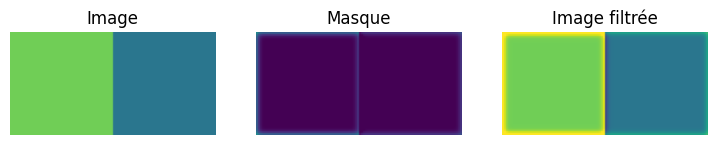

In [44]:
fig,ax = plt.subplots(1,3,figsize=(9,3))

# Test 1
im = np.ones((50, 100)) * 200
im[:, 50:100] = 100
ax[0].imshow(im,vmin=0,vmax=255)
ax[0].set_axis_off()
ax[0].set_title('Image')
#
# A COMPLETER
sigma = 1.5
mask = get_mask(im, sigma)
ax[1].imshow(mask,vmin=0,vmax=255)
ax[1].set_axis_off()
ax[1].set_title('Masque')
#
# A COMPLETER
alpha = 1.2
im_masked = apply_mask(im, mask, alpha)
ax[2].imshow(im_masked,vmin=0,vmax=255)
ax[2].set_axis_off()
ax[2].set_title('Image filtrée')



Pour comprendre le fonctionnement du filtre, nous allons visualiser ce qui se passe sur une ligne horizontale de l'image.

Le code dans la cellule ci-dessous prend la ligne du milieu (y=50) de l'image et du masque et visualise les effets de l'opération.

* Expliquer pourquoi cet operateur augmente le contraste entre les regions sombre et claire.

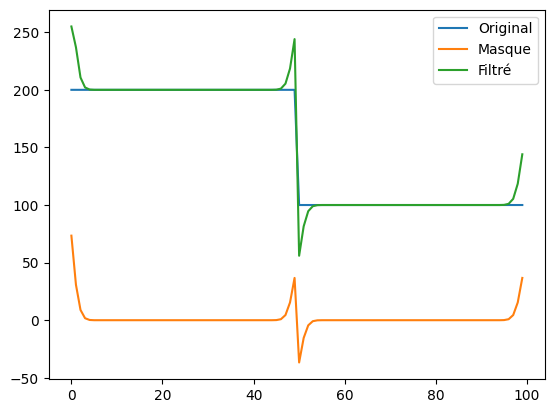

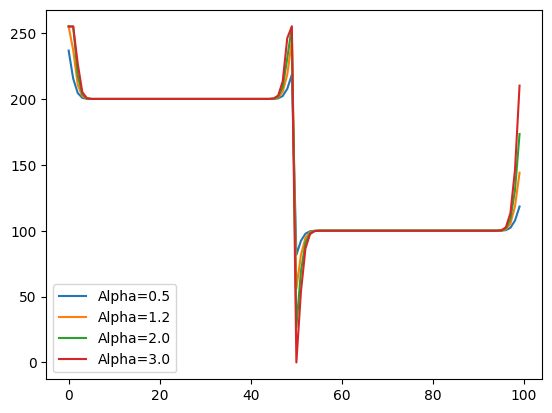

In [45]:
# Extrait la ligne du milieu de l'image avant et apres masquage
im_row = im[25, :]
mask_row = mask[25, :]

# Retrouve l'image filtree par le filtre gaussien
# A COMPLETER
masked_row = np.clip(im_row + alpha * mask_row, 0, 255)

# Afficher les 3 lignes ensemble
fig, ax = plt.subplots()
ax.plot(im_row,label='Original')
ax.plot(mask_row,label='Masque')
ax.plot(masked_row,label='Filtré')
ax.legend()

# Effet du masque flou sur l'image pour diffèrentes valeurs de alpha
test_alphas = []
labels_alpha = []
fig,ax =plt.subplots()
for alpha in [0.5, 1.2, 2.0, 3.0]:
    im_masked_row = np.clip(im_row + alpha * mask_row, 0, 255)
    ax.plot(im_masked_row, label=f"Alpha={alpha}")
ax.legend()


* Testez avec l'image sweets.bmp pour différentes valeurs de $\alpha$ : 1, 5, 10.

Check f(L)   >  0.001: 0.0038659201394728076
Check f(L+1) <= 0.001: 0.00033546262790251185


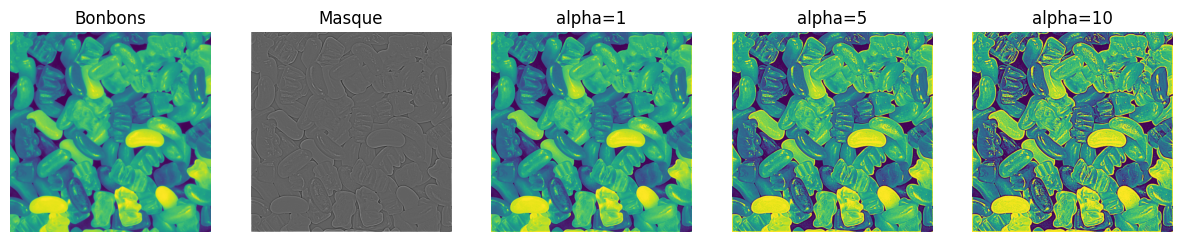

In [48]:
alpha = [1, 5, 10]
fig,ax = plt.subplots(1,2+len(alpha),figsize=(3*(len(alpha)+2),3))
# Test 2
test_img = plt.imread('./sweets.bmp')
ax[0].imshow(test_img,vmin=0,vmax=255)
ax[0].set_axis_off()
ax[0].set_title('Bonbons')

#
# A COMPLETER
sigma = 1.5
mask = get_mask(test_img, sigma)
# Afficher
ax[1].imshow(mask, vmin=mask.min(), vmax=mask.max(), cmap='gray')
ax[1].set_axis_off()
ax[1].set_title('Masque')

#
for i,a in enumerate(alpha):
  test_img_masked = apply_mask(test_img, mask, a)  # Utilisation de la fonction apply_mask
  ax[2+i].imshow(test_img_masked,vmin=0,vmax=255)
  ax[2+i].set_axis_off()
  ax[2+i].set_title(f'alpha={a}')


plt.show()
  
